# ARP Spoofing Detection with Machine Learning

This notebook implements an offline experimental simulation for detecting ARP spoofing using Machine Learning.

The goal is to compare different supervised ML models using:
- packet-level classification;
- window-level alert generation;
- feature selection;
- false positives and false negatives;
- training time and inference time.

The dataset used is the Kitsune Network Attack Dataset (https://www.kaggle.com/datasets/ymirsky/network-attack-dataset-kitsune), ARP MitM scenario.

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils import shuffle

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset Loading

The ARP MitM dataset contains 115 features already extracted from network traffic. Each row represents a packet or its network context, while the labels indicate whether the traffic is benign or malicious.

The Kitsune ARP MitM dataset is temporally ordered.
This means that the first part of the capture contains benign traffic, while the attack starts later.  
For this reason, a simple temporal train/test split would not be suitable for supervised learning, because the training set could contain only benign packets.
First, we load the labels and identify the first malicious packet.

In [2]:
DATASET_PATH = "data/ARP_MitM_dataset.csv"
LABELS_PATH = "data/ARP_MitM_labels.csv"

# Load labels and take value in the last column
labels_raw = pd.read_csv(LABELS_PATH, header=None)
label_col = labels_raw.iloc[:, -1]
y_full = pd.to_numeric(label_col, errors="coerce").dropna().astype(int).reset_index(drop=True)

y_full.name = "label"

class_counts = y_full.value_counts().sort_index()
class_percentages = y_full.value_counts(normalize=True).sort_index() * 100

print("Number of labels:", len(y_full))

print("\nClass distribution:")
print(class_counts)

print("\nClass distribution (%):")
print(class_percentages)

Number of labels: 2504267

Class distribution:
label
0    1358995
1    1145272
Name: count, dtype: int64

Class distribution (%):
label
0    54.267177
1    45.732823
Name: proportion, dtype: float64


In [3]:
y_array_full = y_full.to_numpy()

attack_indices_full = np.where(y_array_full == 1)[0]
benign_indices_full = np.where(y_array_full == 0)[0]

if len(attack_indices_full) == 0:
    raise ValueError("No malicious packets were found. The label file does not contain class 1.")

attack_start = attack_indices_full[0]

print("First malicious packet index:", attack_start)
print("Benign packets before the attack:", attack_start)
print("Total benign packets:", len(benign_indices_full))
print("Total malicious packets:", len(attack_indices_full))

First malicious packet index: 1300000
Benign packets before the attack: 1300000
Total benign packets: 1358995
Total malicious packets: 1145272


## 2. Controlled experimental design

The Kitsune ARP MitM dataset is temporally ordered, but for this experiment we want a controlled window-based test stream.
The training set is balanced and used for supervised learning.
The test set is built as a sequence of windows. Each window contains a known percentage of malicious packets:
- 0% attack traffic;
- 1% attack traffic;
- 5% attack traffic;
- 10% attack traffic;
- 50% attack traffic;
- 100% attack traffic.

The packets are still real packets from the dataset. Only the composition of the test windows is controlled.

In [4]:
# Training set size
N_TRAIN_BENIGN = 50_000
N_TRAIN_ATTACK = 50_000

# Controlled test stream configuration
TEST_WINDOW_SIZE = 1000

# (attack_ratio_inside_window, number_of_windows)
window_plan = [
    (0.00, 20),
    (0.005, 10),
    (0.01, 10),
    (0.02, 10),
    (0.03, 10),
    (0.04, 10),
    (0.05, 10),
    (0.06, 10),
    (0.08, 10),
    (0.10, 10),
]

WINDOW_ALERT_THRESHOLD = 0.05

# Count how many benign and malicious packets are needed for the controlled test stream
N_TEST_ATTACK = sum(
    int(TEST_WINDOW_SIZE * attack_ratio) * num_windows
    for attack_ratio, num_windows in window_plan
)

N_TEST_BENIGN = sum(
    (TEST_WINDOW_SIZE - int(TEST_WINDOW_SIZE * attack_ratio)) * num_windows
    for attack_ratio, num_windows in window_plan
)

N_TEST_TOTAL = N_TEST_ATTACK + N_TEST_BENIGN
N_TEST_WINDOWS = sum(num_windows for _, num_windows in window_plan)

print("Training benign packets:", N_TRAIN_BENIGN)
print("Training attack packets:", N_TRAIN_ATTACK)

print("\nControlled test stream:")
print("Test windows:", N_TEST_WINDOWS)
print("Test window size:", TEST_WINDOW_SIZE)
print("Test total packets:", N_TEST_TOTAL)
print("Test benign packets:", N_TEST_BENIGN)
print("Test attack packets:", N_TEST_ATTACK)

Training benign packets: 50000
Training attack packets: 50000

Controlled test stream:
Test windows: 110
Test window size: 1000
Test total packets: 110000
Test benign packets: 106050
Test attack packets: 3950


## 3. Load only the required feature rows

The full feature file is very large, so only the required rows are loaded.
The code loads enough rows to include:
- clean benign packets before the attack starts;
- enough malicious packets for training and testing.

In [5]:
# Convert the full label vector to a NumPy array
y_array_full = y_full.to_numpy()

# Indices of malicious packets in the full label vector
attack_indices_full = np.where(y_array_full == 1)[0]

# Indices of benign packets before the first attack packet
clean_benign_indices_full = np.where(
    (y_array_full == 0) & (np.arange(len(y_array_full)) < attack_start)
)[0]

required_benign_packets = N_TRAIN_BENIGN + N_TEST_BENIGN
required_attack_packets = N_TRAIN_ATTACK + N_TEST_ATTACK

if len(clean_benign_indices_full) < required_benign_packets:
    raise ValueError(
        f"Not enough clean benign packets. Required: {required_benign_packets}, "
        f"available: {len(clean_benign_indices_full)}"
    )

if len(attack_indices_full) < required_attack_packets:
    raise ValueError(
        f"Not enough malicious packets. Required: {required_attack_packets}, "
        f"available: {len(attack_indices_full)}"
    )

# Load enough rows to include the required number of malicious packets.
last_required_attack_index = attack_indices_full[required_attack_packets - 1]
required_rows = last_required_attack_index + 1

print("Rows to load from feature file:", required_rows)

X = pd.read_csv(
    DATASET_PATH,
    header=None,
    nrows=required_rows,
    dtype=np.float32
)

y = y_full.iloc[:required_rows].reset_index(drop=True)

# Add artificial feature names since the dataset has no headers
feature_names = [f"feature_{i}" for i in range(1, X.shape[1] + 1)]
X.columns = feature_names

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

if len(X) != len(y):
    raise ValueError("Feature matrix and label vector have different lengths.")

X.head()

Rows to load from feature file: 1356774
Feature matrix shape: (1356774, 115)
Label vector shape: (1356774,)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115
0,1.000000,1294.0,0.000000e+00,1.000000,1294.0,0.000000e+00,1.000000,1294.0,0.000000e+00,1.000000,...,0.000000e+00,0.0,0.0,1.000000,1294.0,0.000000,1294.0,0.000000e+00,0.0,0.0
1,1.000000,1514.0,0.000000e+00,1.000000,1514.0,0.000000e+00,1.000000,1514.0,0.000000e+00,1.000000,...,0.000000e+00,0.0,0.0,1.000000,1514.0,0.000000,1514.0,0.000000e+00,0.0,0.0
2,1.999505,1294.0,6.984919e-10,1.999703,1294.0,2.328306e-10,1.999901,1294.0,6.984919e-10,1.999990,...,0.000000e+00,0.0,0.0,1.999999,1294.0,0.000000,1294.0,0.000000e+00,0.0,0.0
3,2.998985,1294.0,9.313226e-10,2.999391,1294.0,4.656613e-10,2.999797,1294.0,6.984919e-10,2.999980,...,6.984919e-10,0.0,0.0,2.999998,1294.0,0.000015,1294.0,2.328306e-10,0.0,0.0
4,3.998061,1294.0,9.313226e-10,3.998836,1294.0,2.328306e-10,3.999612,1294.0,6.984919e-10,3.999961,...,2.328306e-10,0.0,0.0,3.999996,1294.0,0.000000,1294.0,0.000000e+00,0.0,0.0


## 4. Build the training set and the controlled test stream

The supervised training set is balanced (50% benign packets, 50% malicious packets).
The test stream is composed of controlled windows and each window contains a predefined ratio of benign and malicious packets. Within each window, packets are shuffled so that malicious packets are mixed with benign packets.

In [6]:
y_array = y.to_numpy()

# Clean benign packets: benign packets before the first attack
clean_benign_indices = np.where(
    (y_array == 0) & (np.arange(len(y_array)) < attack_start)
)[0]

# Malicious packets
attack_indices = np.where(y_array == 1)[0]

rng = np.random.default_rng(RANDOM_STATE)

# Build a balanced supervised training set

train_benign_idx = rng.choice(
    clean_benign_indices,
    size=N_TRAIN_BENIGN,
    replace=False
)

train_attack_idx = rng.choice(
    attack_indices,
    size=N_TRAIN_ATTACK,
    replace=False
)

train_idx = np.concatenate([train_benign_idx, train_attack_idx])
train_idx = shuffle(train_idx, random_state=RANDOM_STATE)

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

# Remove training packets from the test pools so that they are not chosen again
available_benign_idx = np.setdiff1d(
    clean_benign_indices,
    train_benign_idx,
    assume_unique=False
)

available_attack_idx = np.setdiff1d(
    attack_indices,
    train_attack_idx,
    assume_unique=False
)

available_benign_idx = rng.permutation(available_benign_idx)
available_attack_idx = rng.permutation(available_attack_idx)

if len(available_benign_idx) < N_TEST_BENIGN:
    raise ValueError("Not enough benign packets available for the controlled test stream.")

if len(available_attack_idx) < N_TEST_ATTACK:
    raise ValueError("Not enough attack packets available for the controlled test stream.")

# Build a controlled window-based test stream
test_indices = []
constructed_window_records = []

benign_pointer = 0
attack_pointer = 0
window_id = 0

for attack_ratio, num_windows in window_plan:
    for _ in range(num_windows):
        n_attack = int(TEST_WINDOW_SIZE * attack_ratio)
        n_benign = TEST_WINDOW_SIZE - n_attack
        
        benign_window_idx = available_benign_idx[
            benign_pointer:benign_pointer + n_benign
        ]
        
        attack_window_idx = available_attack_idx[
            attack_pointer:attack_pointer + n_attack
        ]
        
        benign_pointer += n_benign
        attack_pointer += n_attack
        
        # Mix benign and malicious packets inside the same window
        window_idx = np.concatenate([benign_window_idx, attack_window_idx])
        window_idx = rng.permutation(window_idx)
        
        test_indices.extend(window_idx)
        
        constructed_window_records.append({
            "window_id": window_id,
            "target_attack_ratio": attack_ratio,
            "n_benign": n_benign,
            "n_attack": n_attack,
            "true_window_label": int(attack_ratio >= WINDOW_ALERT_THRESHOLD)
        })
        
        window_id += 1

test_idx = np.array(test_indices)

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()

constructed_windows_df = pd.DataFrame(constructed_window_records)

# Verify the actual attack ratio in each constructed window
actual_ratios = []

y_test_array = y_test.to_numpy()

for start in range(0, len(y_test_array), TEST_WINDOW_SIZE):
    end = start + TEST_WINDOW_SIZE
    actual_ratios.append(y_test_array[start:end].mean())

constructed_windows_df["actual_attack_ratio"] = actual_ratios

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

print("\nConstructed windows:")
display(constructed_windows_df.head(15))

print("\nWindow ratio summary:")
display(
    constructed_windows_df.groupby("target_attack_ratio").agg({
        "window_id": "count",
        "n_benign": "mean",
        "n_attack": "mean",
        "actual_attack_ratio": "mean",
        "true_window_label": "first"
    }).rename(columns={"window_id": "num_windows"})
)

Training set shape: (100000, 115)
Test set shape: (110000, 115)

Training class distribution:
label
0    50000
1    50000
Name: count, dtype: int64

Test class distribution:
label
0    106050
1      3950
Name: count, dtype: int64

Constructed windows:


,window_id,target_attack_ratio,n_benign,n_attack,true_window_label,actual_attack_ratio
0,0,0.0,1000,0,0,0.0
1,1,0.0,1000,0,0,0.0
2,2,0.0,1000,0,0,0.0
3,3,0.0,1000,0,0,0.0
4,4,0.0,1000,0,0,0.0
5,5,0.0,1000,0,0,0.0
6,6,0.0,1000,0,0,0.0
7,7,0.0,1000,0,0,0.0
8,8,0.0,1000,0,0,0.0
9,9,0.0,1000,0,0,0.0



Window ratio summary:


,num_windows,n_benign,n_attack,actual_attack_ratio,true_window_label
target_attack_ratio,,,,,
0.000,20,1000.0,0.0,0.000,0
0.005,10,995.0,5.0,0.005,0
0.010,10,990.0,10.0,0.010,0
0.020,10,980.0,20.0,0.020,0
0.030,10,970.0,30.0,0.030,0
0.040,10,960.0,40.0,0.040,0
0.050,10,950.0,50.0,0.050,1
0.060,10,940.0,60.0,0.060,1
0.080,10,920.0,80.0,0.080,1


## 5. Visualization of the controlled test stream

The test stream is made of controlled windows. Some windows are fully benign, some contain a small amount of malicious packets, and others contain stronger attack traffic.

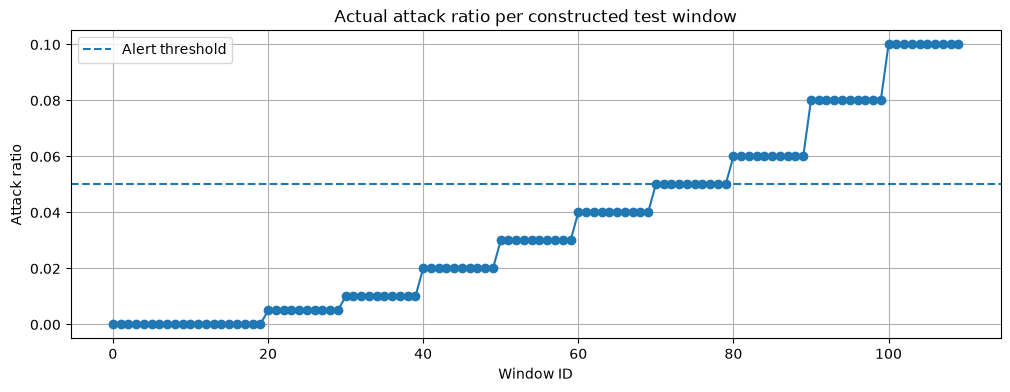

In [7]:
# Plot constructed attack ratios
plt.figure(figsize=(12, 4))
plt.plot(
    constructed_windows_df["window_id"],
    constructed_windows_df["actual_attack_ratio"],
    marker="o"
)
plt.axhline(WINDOW_ALERT_THRESHOLD, linestyle="--", label="Alert threshold")
plt.title("Actual attack ratio per constructed test window")
plt.xlabel("Window ID")
plt.ylabel("Attack ratio")
plt.legend()
plt.grid(True)
plt.show()

## 6. Model definition

The following supervised ML models are compared:
- Logistic Regression
- Gaussian Naive Bayes
- Decision Tree
- Random Forest
- Histogram Gradient Boosting

In [8]:
model_specs = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "scale": True
    },
    "Gaussian Naive Bayes": {
        "model": GaussianNB(),
        "scale": True
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),
        "scale": False
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "scale": False
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),
        "scale": False
    }
}

## 7. Feature selection

The original feature matrix contains 115 numerical features. Three feature configurations are compared:
- all features
- top 40 features
- top 20 features
Feature selection is performed only on the training set to avoid data leakage.

In [9]:
def build_pipeline(model_name, feature_count):
    """
    Build a scikit-learn pipeline.

    Parameters
        model_name:
            Name of the model
    
        feature_count:
            Either "all" or an integer number of selected features

    Returns a sklearn Pipeline
    """
    
    spec = model_specs[model_name]
    model = clone(spec["model"])
    steps = []
    
    # Feature selection is fitted only on the training data with SelectKBest using ANOVA F-value
    if feature_count != "all":
        steps.append(
            ("feature_selection", SelectKBest(score_func=f_classif, k=feature_count))
        )
    
    # Scaling is used only for models that benefit from it
    if spec["scale"]:
        steps.append(("scaler", StandardScaler()))
    
    steps.append(("classifier", model))
    
    return Pipeline(steps)

## 8. Evaluation functions

The experiment uses two levels of evaluation.

### Packet-level evaluation
The model predicts each packet individually.

### Window-level evaluation
Predictions are grouped into windows of fixed size. A real window is considered malicious if at least 5% of the packets in that window are malicious. A predicted window generates an alert if at least 5% of the packets in that window are predicted as malicious.

In [10]:
def slice_rows(data, start, end):
    if hasattr(data, "iloc"):
        return data.iloc[start:end]
    return data[start:end]


def compute_basic_metrics(y_true, y_pred):
    """
    Compute binary classification metrics
    """
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0,
        "fnr": fn / (fn + tp) if (fn + tp) > 0 else 0
    }


def predict_stream(model, X_stream, window_size):
    """
    Simulate streaming inference by predicting one window at a time.
    Returns all packet-level predictions and the total inference time.
    """
    predictions = []
    
    start_time = time.perf_counter()
    
    for start in range(0, len(X_stream), window_size):
        end = start + window_size
        X_window = slice_rows(X_stream, start, end)
        
        if len(X_window) == 0:
            continue
        
        y_pred_window = model.predict(X_window)
        predictions.append(y_pred_window)
    
    inference_time = time.perf_counter() - start_time
    
    return np.concatenate(predictions), inference_time


def evaluate_windows(y_true, y_pred, window_size=1000, threshold=0.05):
    """
    Evaluate predictions at window level w.r.t. the threshold
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    true_window_labels = []
    pred_window_labels = []
    
    true_attack_ratios = []
    pred_attack_ratios = []
    
    for start in range(0, len(y_true), window_size):
        end = start + window_size
        
        y_true_window = y_true[start:end]
        y_pred_window = y_pred[start:end]
        
        if len(y_true_window) == 0:
            continue
        
        true_attack_ratio = y_true_window.mean()
        pred_attack_ratio = y_pred_window.mean()
        
        true_window_label = int(true_attack_ratio >= threshold)
        pred_window_label = int(pred_attack_ratio >= threshold)
        
        true_window_labels.append(true_window_label)
        pred_window_labels.append(pred_window_label)
        
        true_attack_ratios.append(true_attack_ratio)
        pred_attack_ratios.append(pred_attack_ratio)
    
    metrics = compute_basic_metrics(true_window_labels, pred_window_labels)
    
    metrics.update({
        "num_windows": len(true_window_labels),
        "window_size": window_size,
        "window_threshold": threshold
    })
    
    details = pd.DataFrame({
        "window_id": np.arange(len(true_window_labels)),
        "true_window_label": true_window_labels,
        "pred_window_label": pred_window_labels,
        "true_attack_ratio": true_attack_ratios,
        "pred_attack_ratio": pred_attack_ratios
    })
    
    return metrics, details

## 9. Main experiment

For each model and each feature configuration, measure:
- training and inference time 
- packet-level and window-level metrics
- false positives and false negatives

In [11]:
feature_sets = ["all", 40, 20]

# Use the same window size as the building of test streams
window_sizes = [TEST_WINDOW_SIZE]

results = []
window_details_store = {}

# Run experiment for each feature count and each model
for feature_count in feature_sets:
    for model_name in model_specs.keys():
        
        print(f"Training model: {model_name} | Features: {feature_count}")
        
        pipeline = build_pipeline(model_name, feature_count)
        
        # Training time
        train_start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        train_time = time.perf_counter() - train_start
        
        for window_size in window_sizes:
            
            # Streaming-style inference
            y_pred, inference_time = predict_stream(
                model=pipeline,
                X_stream=X_test,
                window_size=window_size
            )
            
            # Packet-level metrics
            packet_metrics = compute_basic_metrics(
                y_true=y_test.to_numpy(),
                y_pred=y_pred
            )
            
            # Window-level metrics
            window_metrics, window_details = evaluate_windows(
                y_true=y_test.to_numpy(),
                y_pred=y_pred,
                window_size=window_size,
                threshold=WINDOW_ALERT_THRESHOLD
            )
            
            experiment_id = f"{model_name}_features_{feature_count}_window_{window_size}"
            window_details_store[experiment_id] = window_details
            
            row = {
                "model": model_name,
                "features": feature_count,
                "window_size": window_size,
                "window_threshold": WINDOW_ALERT_THRESHOLD,
                "train_time_seconds": train_time,
                "inference_time_seconds": inference_time,
                "inference_time_per_packet_ms": (inference_time / len(X_test)) * 1000,
            }
            
            # Add packet-level metrics
            for key, value in packet_metrics.items():
                row[f"packet_{key}"] = value
            
            # Add window-level 
            for key, value in window_metrics.items():
                row[f"window_{key}"] = value
            
            results.append(row)

results_df = pd.DataFrame(results)

print("Experiment completed.")

Training model: Logistic Regression | Features: all
Training model: Gaussian Naive Bayes | Features: all
Training model: Decision Tree | Features: all
Training model: Random Forest | Features: all
Training model: HistGradientBoosting | Features: all
Training model: Logistic Regression | Features: 40
Training model: Gaussian Naive Bayes | Features: 40
Training model: Decision Tree | Features: 40
Training model: Random Forest | Features: 40
Training model: HistGradientBoosting | Features: 40
Training model: Logistic Regression | Features: 20
Training model: Gaussian Naive Bayes | Features: 20
Training model: Decision Tree | Features: 20
Training model: Random Forest | Features: 20
Training model: HistGradientBoosting | Features: 20
Experiment completed.


## 10. Complete results table

In [12]:
results_df

,model,features,window_size,window_threshold,train_time_seconds,inference_time_seconds,inference_time_per_packet_ms,packet_accuracy,packet_precision,packet_recall,...,window_f1,window_true_negatives,window_false_positives,window_false_negatives,window_true_positives,window_fpr,window_fnr,window_num_windows,window_window_size,window_window_threshold
0,Logistic Regression,all,1000,0.05,3.770202,0.212097,0.001928,0.991845,0.815197,0.999494,...,0.930233,64,6,0,40,0.085714,0.0,110,1000,0.05
1,Gaussian Naive Bayes,all,1000,0.05,0.306870,0.285912,0.002599,0.316145,0.045063,0.893671,...,0.533333,0,70,0,40,1.000000,0.0,110,1000,0.05
2,Decision Tree,all,1000,0.05,6.622857,0.183068,0.001664,0.999918,0.997727,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
3,Random Forest,all,1000,0.05,8.579523,3.246958,0.029518,0.999964,0.998988,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
4,HistGradientBoosting,all,1000,0.05,6.918736,0.680326,0.006185,0.999955,0.998736,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
5,Logistic Regression,40,1000,0.05,1.721094,0.221518,0.002014,0.982991,0.678700,0.999494,...,0.860215,57,13,0,40,0.185714,0.0,110,1000,0.05
6,Gaussian Naive Bayes,40,1000,0.05,0.184521,0.252935,0.002299,0.276382,0.046985,0.993165,...,0.533333,0,70,0,40,1.000000,0.0,110,1000,0.05
7,Decision Tree,40,1000,0.05,2.991714,0.201978,0.001836,0.999691,0.991466,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
8,Random Forest,40,1000,0.05,8.129109,3.187481,0.028977,0.999855,0.995966,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
9,HistGradientBoosting,40,1000,0.05,1.711232,0.666486,0.006059,0.999727,0.992462,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05


## 11. Best configurations

The best configurations are sorted by different scores:
1. highest window-level F1-score
2. lowest number of window-level false negatives
3. lowest number of window-level false positives
4. lowest inference time

In [13]:
best_results = results_df.sort_values(
    by=[
        "window_f1",
        "window_false_negatives",
        "window_false_positives",
        "inference_time_seconds"
    ],
    ascending=[False, True, True, True]
)

best_results.head(10)

,model,features,window_size,window_threshold,train_time_seconds,inference_time_seconds,inference_time_per_packet_ms,packet_accuracy,packet_precision,packet_recall,...,window_f1,window_true_negatives,window_false_positives,window_false_negatives,window_true_positives,window_fpr,window_fnr,window_num_windows,window_window_size,window_window_threshold
12,Decision Tree,20,1000,0.05,1.332982,0.163615,0.001487,0.999527,0.987006,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
2,Decision Tree,all,1000,0.05,6.622857,0.183068,0.001664,0.999918,0.997727,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
7,Decision Tree,40,1000,0.05,2.991714,0.201978,0.001836,0.999691,0.991466,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
9,HistGradientBoosting,40,1000,0.05,1.711232,0.666486,0.006059,0.999727,0.992462,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
14,HistGradientBoosting,20,1000,0.05,1.208781,0.668780,0.006080,0.999564,0.988238,0.999747,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
4,HistGradientBoosting,all,1000,0.05,6.918736,0.680326,0.006185,0.999955,0.998736,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
13,Random Forest,20,1000,0.05,5.439621,3.139895,0.028545,0.999736,0.992712,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
8,Random Forest,40,1000,0.05,8.129109,3.187481,0.028977,0.999855,0.995966,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
3,Random Forest,all,1000,0.05,8.579523,3.246958,0.029518,0.999964,0.998988,1.000000,...,1.000000,70,0,0,40,0.000000,0.0,110,1000,0.05
0,Logistic Regression,all,1000,0.05,3.770202,0.212097,0.001928,0.991845,0.815197,0.999494,...,0.930233,64,6,0,40,0.085714,0.0,110,1000,0.05


## 12. Packet-level comparison

Packet-level metrics evaluate the model on individual packets.
The most relevant values are:
- precision
- recall
- F1-score
- false positives
- false negatives

In [14]:
packet_summary = results_df[[
    "model",
    "features",
    "train_time_seconds",
    "inference_time_seconds",
    "packet_accuracy",
    "packet_precision",
    "packet_recall",
    "packet_f1",
    "packet_false_positives",
    "packet_false_negatives",
    "packet_fpr",
    "packet_fnr"
]].sort_values(
    by=["packet_f1", "packet_false_negatives"],
    ascending=[False, True]
).reset_index(drop=True)

packet_summary.index = packet_summary.index + 1

packet_summary

,model,features,train_time_seconds,inference_time_seconds,packet_accuracy,packet_precision,packet_recall,packet_f1,packet_false_positives,packet_false_negatives,packet_fpr,packet_fnr
1,Random Forest,all,8.579523,3.246958,0.999964,0.998988,1.000000,0.999494,4,0,0.000038,0.000000
2,HistGradientBoosting,all,6.918736,0.680326,0.999955,0.998736,1.000000,0.999367,5,0,0.000047,0.000000
3,Decision Tree,all,6.622857,0.183068,0.999918,0.997727,1.000000,0.998862,9,0,0.000085,0.000000
4,Random Forest,40,8.129109,3.187481,0.999855,0.995966,1.000000,0.997979,16,0,0.000151,0.000000
5,Random Forest,20,5.439621,3.139895,0.999736,0.992712,1.000000,0.996343,29,0,0.000273,0.000000
6,HistGradientBoosting,40,1.711232,0.666486,0.999727,0.992462,1.000000,0.996217,30,0,0.000283,0.000000
7,Decision Tree,40,2.991714,0.201978,0.999691,0.991466,1.000000,0.995715,34,0,0.000321,0.000000
8,HistGradientBoosting,20,1.208781,0.668780,0.999564,0.988238,0.999747,0.993959,47,1,0.000443,0.000253
9,Decision Tree,20,1.332982,0.163615,0.999527,0.987006,1.000000,0.993461,52,0,0.000490,0.000000
10,Logistic Regression,all,3.770202,0.212097,0.991845,0.815197,0.999494,0.897987,895,2,0.008439,0.000506


## 13. Window-level comparison

Window-level metrics evaluate the alert generation mechanism.
A false positive at window level means that the detector generated an alert for a benign or almost benign window.
A false negative at window level means that the detector failed to generate an alert for an attack window.

In [15]:
window_summary = results_df[[
    "model",
    "features",
    "window_size",
    "window_threshold",
    "inference_time_seconds",
    "window_accuracy",
    "window_precision",
    "window_recall",
    "window_f1",
    "window_false_positives",
    "window_false_negatives",
    "window_fpr",
    "window_fnr"
]].sort_values(
    by=["window_f1", "window_false_negatives", "window_false_positives"],
    ascending=[False, True, True]
).reset_index(drop=True)

window_summary.index = window_summary.index + 1

window_summary

,model,features,window_size,window_threshold,inference_time_seconds,window_accuracy,window_precision,window_recall,window_f1,window_false_positives,window_false_negatives,window_fpr,window_fnr
1,Decision Tree,all,1000,0.05,0.183068,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
2,Random Forest,all,1000,0.05,3.246958,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
3,HistGradientBoosting,all,1000,0.05,0.680326,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
4,Decision Tree,40,1000,0.05,0.201978,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
5,Random Forest,40,1000,0.05,3.187481,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
6,HistGradientBoosting,40,1000,0.05,0.666486,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
7,Decision Tree,20,1000,0.05,0.163615,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
8,Random Forest,20,1000,0.05,3.139895,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
9,HistGradientBoosting,20,1000,0.05,0.668780,1.000000,1.000000,1.0,1.000000,0,0,0.000000,0.0
10,Logistic Regression,all,1000,0.05,0.212097,0.945455,0.869565,1.0,0.930233,6,0,0.085714,0.0


## 14. Effect of feature selection

This section compares the use of:
- all 115 features
- the top 40 selected features
- the top 20 selected features

The goal is to check whether a smaller feature set can reduce execution time without significantly reducing detection performance.

In [16]:
feature_summary = results_df.groupby("features").agg({
    "window_f1": "mean",
    "window_precision": "mean",
    "window_recall": "mean",
    "window_false_positives": "mean",
    "window_false_negatives": "mean",
    "train_time_seconds": "mean",
    "inference_time_seconds": "mean",
    "inference_time_per_packet_ms": "mean"
}).sort_values(
    by=["window_precision"],
    ascending=[False]
)

feature_summary

,window_f1,window_precision,window_recall,window_false_positives,window_false_negatives,train_time_seconds,inference_time_seconds,inference_time_per_packet_ms
features,,,,,,,,
all,0.892713,0.846640,1.0,15.2,0.0,5.239638,0.921672,0.008379
40,0.878710,0.823671,1.0,16.6,0.0,2.947534,0.906080,0.008237
20,0.868283,0.808320,1.0,17.8,0.0,1.756016,0.871332,0.007921


## 15. Plot: window-level F1-score by model

The following plot compares the window-level F1-score of the models.

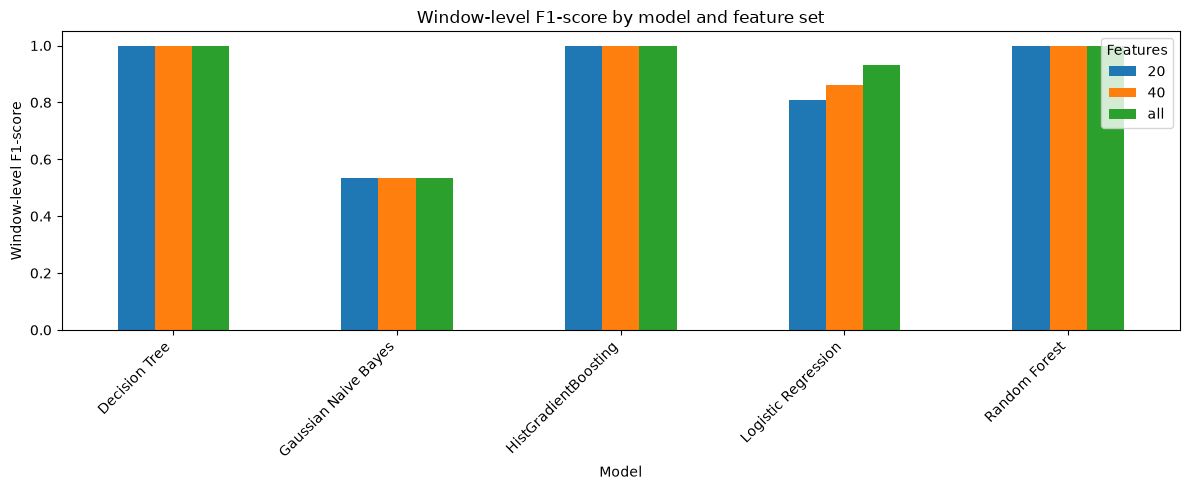

In [17]:
pivot_f1 = results_df.pivot_table(
    index="model",
    columns="features",
    values="window_f1",
    aggfunc="mean"
)

pivot_f1.plot(kind="bar", figsize=(12, 5))
plt.title("Window-level F1-score by model and feature set")
plt.xlabel("Model")
plt.ylabel("Window-level F1-score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Features")
plt.tight_layout()
plt.show()

## 16. Plot: inference time by model

This plot compares inference time. Lower inference time means the model is more suitable for fast detection.

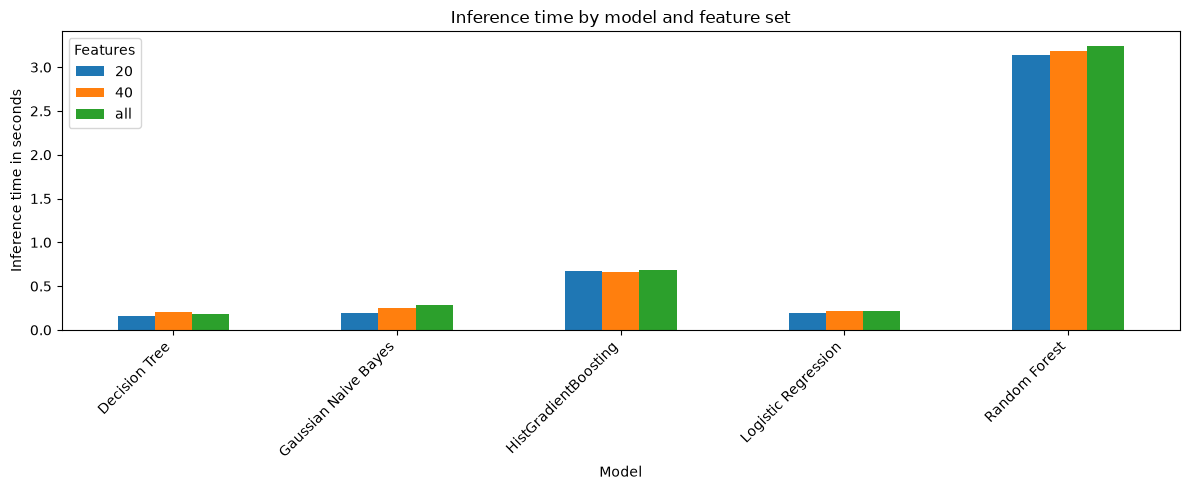

In [18]:
pivot_time = results_df.pivot_table(
    index="model",
    columns="features",
    values="inference_time_seconds",
    aggfunc="mean"
)

pivot_time.plot(kind="bar", figsize=(12, 5))
plt.title("Inference time by model and feature set")
plt.xlabel("Model")
plt.ylabel("Inference time in seconds")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Features")
plt.tight_layout()
plt.show()

## 17. Visualize alerts for a selected model

This section shows how one selected model (default choiche is Logistic Regression) behaves over the controlled test stream. The true attack ratio and the predicted attack ratio are shown for each test window.

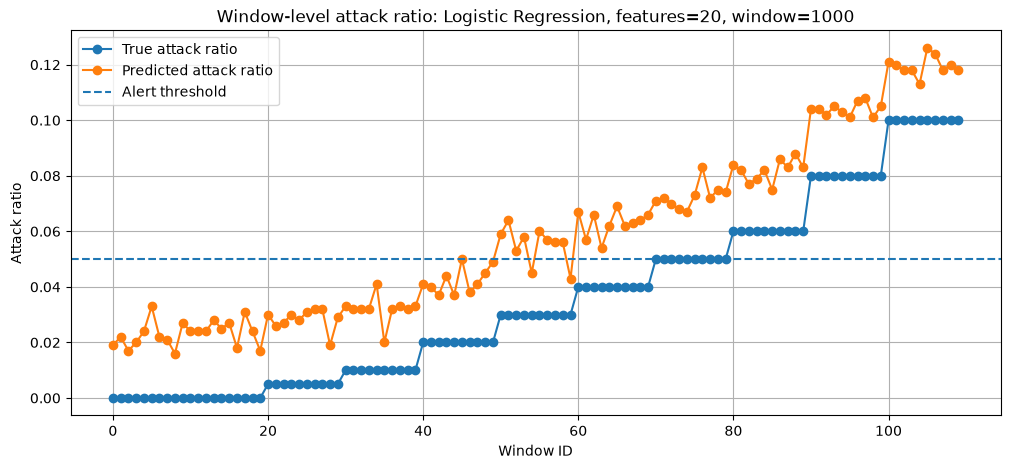

In [19]:
selected_model = "Logistic Regression"
selected_features = 20
selected_window_size = TEST_WINDOW_SIZE

selected_experiment_id = f"{selected_model}_features_{selected_features}_window_{selected_window_size}"

if selected_experiment_id not in window_details_store:
    raise ValueError("Selected experiment not found. Check model name, feature count, and window size.")

selected_details = window_details_store[selected_experiment_id]

selected_details.head()

plt.figure(figsize=(12, 5))
plt.plot(
    selected_details["window_id"],
    selected_details["true_attack_ratio"],
    marker="o",
    label="True attack ratio"
)
plt.plot(
    selected_details["window_id"],
    selected_details["pred_attack_ratio"],
    marker="o",
    label="Predicted attack ratio"
)
plt.axhline(WINDOW_ALERT_THRESHOLD, linestyle="--", label="Alert threshold")
plt.title(
    f"Window-level attack ratio: {selected_model}, "
    f"features={selected_features}, window={selected_window_size}"
)
plt.xlabel("Window ID")
plt.ylabel("Attack ratio")
plt.legend()
plt.grid(True)
plt.show()

## 18. Save results 

The final results are saved as CSV files.

In [20]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

results_df.to_csv(RESULTS_DIR / "full_results.csv", index=False)
packet_summary.to_csv(RESULTS_DIR / "packet_summary.csv", index=False)
window_summary.to_csv(RESULTS_DIR / "window_summary.csv", index=False)
feature_summary.to_csv(RESULTS_DIR / "feature_summary.csv", index=False)
constructed_windows_df.to_csv(RESULTS_DIR / "constructed_windows.csv", index=False)

print("Results saved in the 'results' folder.")

Results saved in the 'results' folder.
